# Customer Churn Prediction: A Classification Project

Welcome! In this Jupyter Notebook, we will walk through a complete, end-to-end Machine Learning project to predict **Customer Churn**. Customer churn refers to the phenomenon where customers stop doing business with a company. Predicting churn is a classic and highly valuable business application of **binary classification** in machine learning.

### What You'll Learn in This Notebook:
1. **Exploratory Data Analysis (EDA)**: Understanding data distributions, identifying missing values, analyzing correlation, and visualizing target class imbalance.
2. **Data Preprocessing & Cleaning**: Handling missing values, encoding categorical variables, and scaling numeric features.
3. **Model Selection & Training**: Training three popular classification algorithms: *Logistic Regression*, *Decision Tree*, and *Random Forest*.
4. **Classification Metrics & Evaluation**: Diving deep into accuracy, precision, recall, F1-score, and ROC-AUC.
5. **Confusion Matrix Analysis**: Interpreting true positives, false positives, true negatives, and false negatives in a business context.
6. **Feature Importance**: Identifying which factors drive customer churn the most.
7. **Predicting on New Data**: Applying the trained model to new customer profiles to make real-world decisions.

---
## 1. Environment Setup & Library Imports

First, we import the core Python libraries required for data manipulation, visualization, and machine learning. We will use standard libraries like **Pandas**, **NumPy**, **Matplotlib**, **Seaborn**, and **Scikit-learn**.


In [1]:
# Standard libraries for data analysis
import numpy as np
import pandas as pd

# Libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries from Scikit-Learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

# Visual settings
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# Suppress warnings for clean output
import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully!')


All libraries imported successfully!


## 2. Loading the Dataset

We will load our customer dataset from a CSV file named `customer_churn.csv`. Let's read it into a Pandas DataFrame and perform an initial inspection to understand its structure, columns, and data types.


In [2]:
# Load the dataset
df = pd.read_csv('customer_churn.csv')

# In real-world datasets (like this Kaggle/IBM Telco Churn dataset), numerical columns 
# can sometimes contain formatting anomalies (like blank spaces for new customers with tenure=0)
# which causes them to be loaded as strings (object type). We force TotalCharges to be numeric,
# converting any blank spaces or invalid values to NaN.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Display the dimensions of the dataset (rows, columns)
print(f'Dataset Shape: {df.shape}')

# View the first 5 records
df.head()


Dataset Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


To get a higher-level summary of the columns, their non-null counts, and data types, we use `.info()`. To see basic statistics for numerical variables, we use `.describe()`.


In [3]:
# Detailed summary of the dataset
df.info()

# Summary statistics for numerical variables
df.describe().T


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.00,0.000,0.0000,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.000,55.0000,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.350,89.8500,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.45,1397.475,3794.7375,8684.80


## 3. Exploratory Data Analysis (EDA)

EDA is a crucial step where we analyze the dataset to summarize its main characteristics, often using visual methods. We will focus on:
1. **Missing values**: Identifying where data is incomplete.
2. **Class distribution**: Checking if the dataset is balanced (equal number of churned and non-churned customers).
3. **Numerical feature distributions**: Visualizing how tenure, monthly charges, and total charges are distributed.
4. **Correlation Analysis**: Checking how numerical features relate to one another.
5. **Categorical features vs Churn**: Exploring how customer segments differ in their churn rates.


In [4]:
# Check for missing values in all columns
missing_values = df.isnull().sum()
print('Missing values per column:')
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else 'No missing values found!')


Missing values per column:
TotalCharges    11
dtype: int64


### 3.1 Class Distribution (Target Variable)
Let's see how many customers have left the service (`Churn = Yes`) versus those who stayed (`Churn = No`). Understanding this is essential because an imbalanced dataset can cause machine learning models to favor the majority class.


Churn = No: 5174 customers (73.46%)
Churn = Yes: 1869 customers (26.54%)


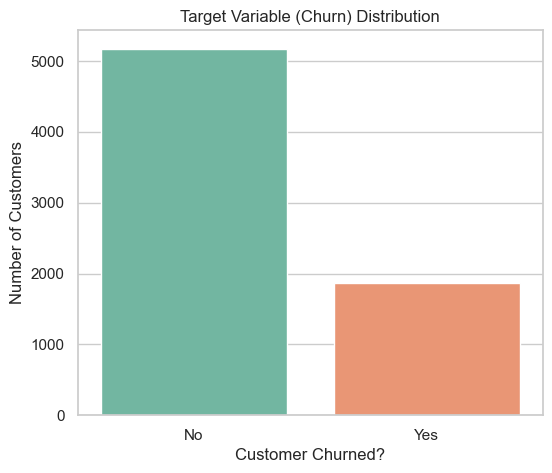

In [5]:
# Get counts and percentages of churn
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

for val, count, pct in zip(churn_counts.index, churn_counts.values, churn_pct.values):
    print(f'Churn = {val}: {count} customers ({pct:.2f}%)')

# Visualize the distribution
plt.figure(figsize=(6, 5))
sns.countplot(x='Churn', data=df, palette='Set2')
plt.title('Target Variable (Churn) Distribution')
plt.xlabel('Customer Churned?')
plt.ylabel('Number of Customers')
plt.show()


### 3.2 Numerical Feature Distributions
We have three main continuous numerical variables: `tenure` (how long the customer has been with the company), `MonthlyCharges`, and `TotalCharges`. Let's plot their distributions to understand their ranges and shapes.


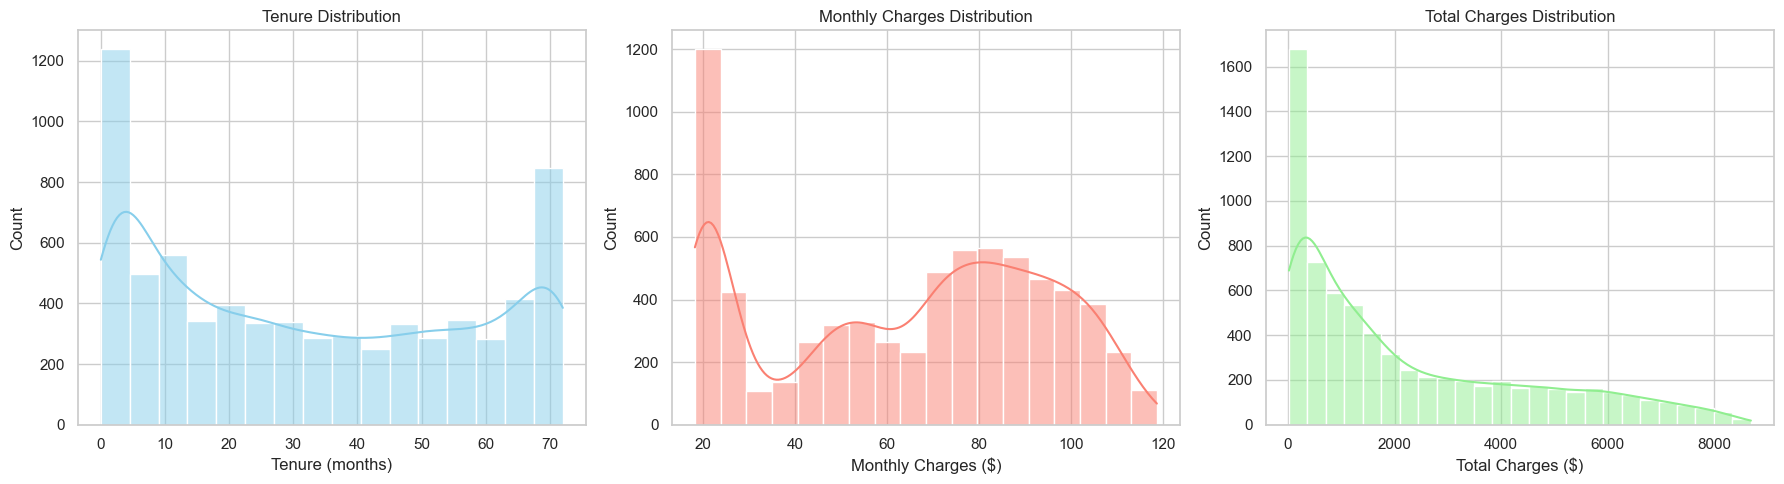

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot Tenure Distribution
sns.histplot(df['tenure'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Tenure Distribution')
axes[0].set_xlabel('Tenure (months)')
axes[0].set_ylabel('Count')

# Plot Monthly Charges Distribution
sns.histplot(df['MonthlyCharges'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Monthly Charges Distribution')
axes[1].set_xlabel('Monthly Charges ($)')
axes[1].set_ylabel('Count')

# Plot Total Charges Distribution (dropna to avoid errors with NaNs)
sns.histplot(df['TotalCharges'].dropna(), kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('Total Charges Distribution')
axes[2].set_xlabel('Total Charges ($)')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()


### 3.3 Correlation Analysis
We want to understand how numerical features relate to one another. Highly correlated features (e.g., tenure and total charges) can sometimes lead to multicollinearity in linear models. We will calculate the Pearson correlation coefficient and plot it as a heatmap.


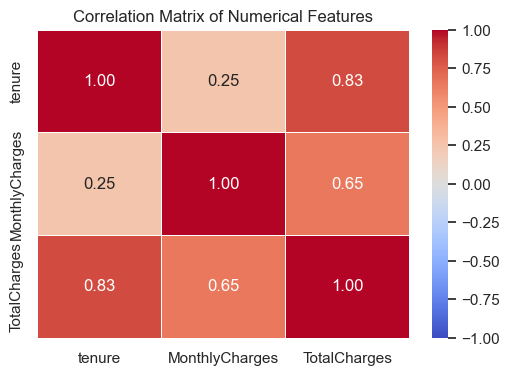

In [7]:
# Calculate correlation matrix for numerical features
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
corr_matrix = df[num_cols].corr()

# Plot the heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix of Numerical Features')
plt.show()


### 3.4 Key Categorical Relationships with Churn
Let's explore how major business features impact churn:
1. **Contract Type**: Do customers with short-term (Month-to-month) contracts churn more than long-term (One or Two year) contracts?
2. **Internet Service**: How does the type of internet connection affect customer retention?


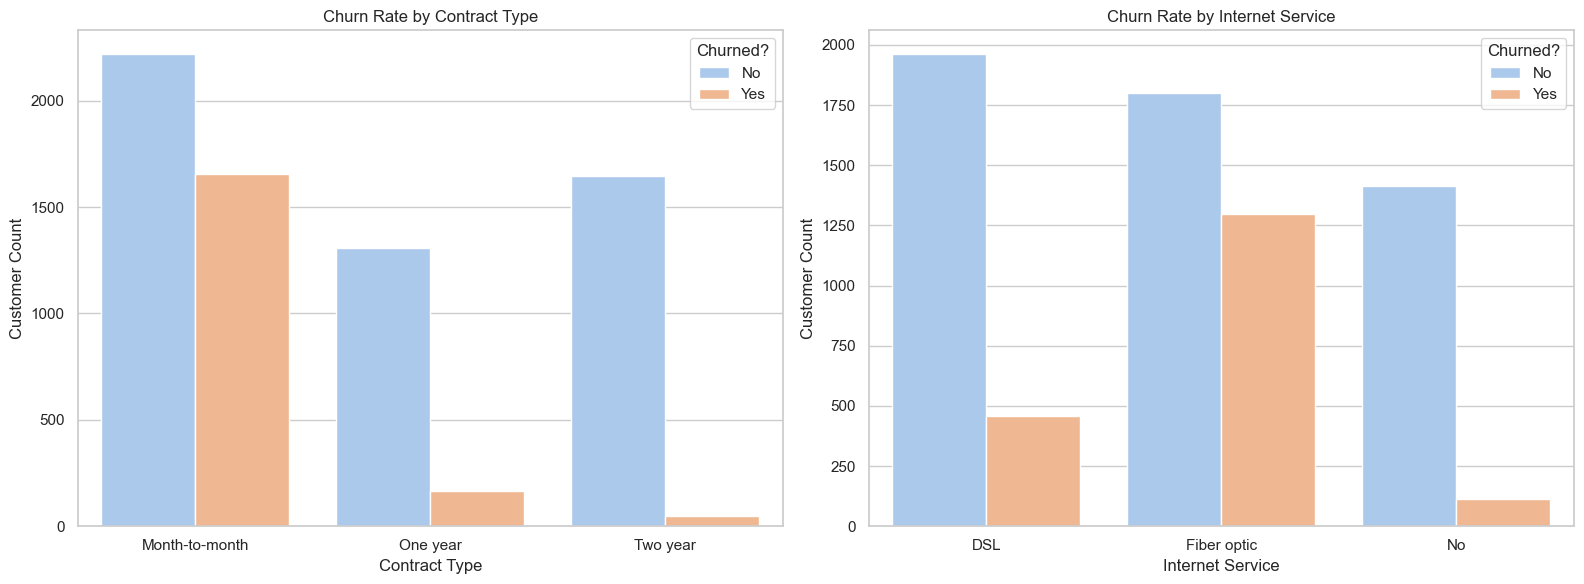

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Contract Type vs Churn
sns.countplot(x='Contract', hue='Churn', data=df, ax=axes[0], palette='pastel')
axes[0].set_title('Churn Rate by Contract Type')
axes[0].set_xlabel('Contract Type')
axes[0].set_ylabel('Customer Count')
axes[0].legend(title='Churned?')

# Internet Service vs Churn
sns.countplot(x='InternetService', hue='Churn', data=df, ax=axes[1], palette='pastel')
axes[1].set_title('Churn Rate by Internet Service')
axes[1].set_xlabel('Internet Service')
axes[1].set_ylabel('Customer Count')
axes[1].legend(title='Churned?')

plt.tight_layout()
plt.show()


## 4. Data Cleaning & Preprocessing

Machine learning models require clean, fully numeric data. In this section, we will:
1. **Handle missing values**: Fill missing values in `TotalCharges`.
2. **Feature & Target definition**: Separate features (`X`) and target variable (`y`), dropping uninformative IDs.
3. **Encode categorical variables**: Convert text columns into binary numeric representations.
4. **Feature Scaling**: Standardize our numeric features to have a mean of 0 and standard deviation of 1.


In [9]:
# Since we forced TotalCharges to be numeric during loading, any blank spaces were turned into NaNs.
# Let's print the number of missing values now.
print(f'Number of missing values in TotalCharges before imputation: {df["TotalCharges"].isnull().sum()}')

# Since TotalCharges is skewed (as seen in our EDA), we will impute missing values with the median
median_total_charges = df['TotalCharges'].median()
df['TotalCharges'].fillna(median_total_charges, inplace=True)

print(f'Number of missing values in TotalCharges after imputation: {df["TotalCharges"].isnull().sum()}')


Number of missing values in TotalCharges before imputation: 11
Number of missing values in TotalCharges after imputation: 0


### 4.1 Categorical Encoding
Most machine learning models cannot handle raw text data. We must convert them into numbers:
- **Target variable (`Churn`)**: We will convert `'Yes'` to `1` and `'No'` to `0`.
- **Binary categorical variables (e.g. `gender`, `Partner`, `Dependents`, `PhoneService`, `PaperlessBilling`)**: We will encode them as 0 or 1.
- **Multi-class categorical variables (e.g. `Contract`, `InternetService`, `PaymentMethod`, `MultipleLines`, services)**: We will use **One-Hot Encoding** (creating dummy variables). We pass `drop_first=True` to avoid the "dummy variable trap" (multicollinearity).


In [10]:
# Step 1: Drop CustomerID as it has no predictive power
df_cleaned = df.drop(columns=['customerID'])

# Step 2: Encode Target Variable 'Churn'
df_cleaned['Churn'] = df_cleaned['Churn'].map({'Yes': 1, 'No': 0})

# Step 3: Identify categorical columns (excluding SeniorCitizen which is already 0/1)
categorical_cols = df_cleaned.select_dtypes(include=['object']).columns.tolist()
print('Categorical columns to encode:', categorical_cols)

# Step 4: Perform One-Hot Encoding
df_preprocessed = pd.get_dummies(df_cleaned, columns=categorical_cols, drop_first=True)

print(f'Preprocessed DataFrame shape: {df_preprocessed.shape}')
df_preprocessed.head()


Categorical columns to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Preprocessed DataFrame shape: (7043, 31)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


### 4.2 Separate Features and Target
We separate the target column `Churn` from the rest of the features.


In [11]:
X = df_preprocessed.drop(columns=['Churn'])
y = df_preprocessed['Churn']

print(f'Features shape (X): {X.shape}')
print(f'Target shape (y): {y.shape}')


Features shape (X): (7043, 30)


Target shape (y): (7043,)


## 5. Train-Test Split

To properly evaluate our models, we split our data into two sets:
1. **Training Set (80%)**: Used to fit the models.
2. **Test Set (20%)**: Kept hidden from the models during training. Used to evaluate how well the models generalize to unseen data.

We use `stratify=y` to ensure that both the training and test sets have the same ratio of churned to non-churned customers as the original dataset.


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training Set: {X_train.shape[0]} rows, {X_train.shape[1]} columns')
print(f'Test Set: {X_test.shape[0]} rows, {X_test.shape[1]} columns')
print(f'Train Churn Rate: {y_train.mean():.2%}')
print(f'Test Churn Rate: {y_test.mean():.2%}')


Training Set: 5634 rows, 30 columns
Test Set: 1409 rows, 30 columns
Train Churn Rate: 26.54%
Test Churn Rate: 26.54%


### 5.1 Feature Scaling
Some models, like Logistic Regression, are sensitive to the scale of input features because they use gradient descent optimization or distance metrics. We scale the continuous numerical variables (`tenure`, `MonthlyCharges`, `TotalCharges`) to have a mean of 0 and a variance of 1 using `StandardScaler`.

**Important Note**: We fit the scaler on the training set *only* and transform both the training and test sets. This prevents "data leakage" (information from the test set leaking into the training process).


In [13]:
# Identify numerical columns to scale
num_cols_to_scale = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Initialize the StandardScaler
scaler = StandardScaler()

# Copy datasets to avoid writing warnings
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Fit and transform on training data, transform on test data
X_train_scaled[num_cols_to_scale] = scaler.fit_transform(X_train[num_cols_to_scale])
X_test_scaled[num_cols_to_scale] = scaler.transform(X_test[num_cols_to_scale])

print('Scaling completed!')
X_train_scaled[num_cols_to_scale].head()


Scaling completed!


,tenure,MonthlyCharges,TotalCharges
3738,0.102371,-0.521976,-0.263289
3151,-0.711743,0.337478,-0.504814
4860,-0.793155,-0.809013,-0.751213
3867,-0.263980,0.284384,-0.173699
3810,-1.281624,-0.676279,-0.990851


## 6. Model Training

We will train three different types of classifiers:
1. **Logistic Regression**: A linear model that predicts probabilities using the logistic sigmoid function. Great as a fast, interpretable baseline.
2. **Decision Tree Classifier**: A non-linear model that splits data based on feature values. Highly interpretable but prone to overfitting.
3. **Random Forest Classifier**: An ensemble model that combines many decision trees using bagging (bootstrap aggregating). It is robust, handles non-linear relationships well, and reduces overfitting.


In [14]:
# 1. Initialize the models
log_reg = LogisticRegression(random_state=42, max_iter=1000)
dec_tree = DecisionTreeClassifier(random_state=42, max_depth=5) # Restrict depth to avoid overfitting
rand_forest = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=10)

# 2. Train the models on scaled data
print('Training Logistic Regression...')
log_reg.fit(X_train_scaled, y_train)

print('Training Decision Tree...')
dec_tree.fit(X_train_scaled, y_train)

print('Training Random Forest...')
rand_forest.fit(X_train_scaled, y_train)

print('All models trained successfully!')


Training Logistic Regression...


Training Decision Tree...


Training Random Forest...


All models trained successfully!


## 7. Model Evaluation

To evaluate classification performance, looking at Accuracy alone is often not enough, especially if classes are imbalanced. We will calculate five core metrics:

1. **Accuracy**: The ratio of correctly predicted observations to the total observations. $$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$
2. **Precision**: The ratio of correctly predicted positive observations to the total predicted positives. High precision means a low false positive rate (i.e. predicting someone will churn when they won't). $$Precision = \frac{TP}{TP + FP}$$
3. **Recall (Sensitivity)**: The ratio of correctly predicted positive observations to all actual positives. High recall means a low false negative rate (i.e. we capture most of the customers who will churn). $$Recall = \frac{TP}{TP + FN}$$
4. **F1-Score**: The harmonic mean of Precision and Recall. Good when you want to balance both. $$F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}$$
5. **ROC-AUC (Area Under the Receiver Operating Characteristic Curve)**: Measures the model's ability to distinguish between classes. A score of 0.5 is equivalent to random guessing, while 1.0 is perfect classification.

Let's write a function to calculate and return these metrics for each model.


In [15]:
def evaluate_model(model, X_test, y_test, name):
    # Get class predictions (0 or 1)
    preds = model.predict(X_test)
    # Get probability predictions for the positive class (Churn = 1)
    probs = model.predict_proba(X_test)[:, 1]
    
    # Calculate metrics
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    auc = roc_auc_score(y_test, probs)
    
    print(f'=== {name} Performance ===')
    print(classification_report(y_test, preds))
    print(f'ROC-AUC Score: {auc:.4f}\n')
    
    return {
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': auc,
        'probs': probs,
        'preds': preds
    }

# Evaluate each model
log_reg_results = evaluate_model(log_reg, X_test_scaled, y_test, 'Logistic Regression')
dec_tree_results = evaluate_model(dec_tree, X_test_scaled, y_test, 'Decision Tree')
rand_forest_results = evaluate_model(rand_forest, X_test_scaled, y_test, 'Random Forest')


=== Logistic Regression Performance ===
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

ROC-AUC Score: 0.8421



=== Decision Tree Performance ===
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1035
           1       0.63      0.55      0.58       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.79      0.79      1409

ROC-AUC Score: 0.8284



=== Random Forest Performance ===
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.53      0.60       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409

ROC-AUC Score: 0.8427



### 7.1 Plotting the ROC Curves
The Receiver Operating Characteristic (ROC) curve plots the True Positive Rate (Recall) against the False Positive Rate ($1 - Specificity$) at various threshold settings. The higher the curve is above the diagonal baseline, the better the model's performance.


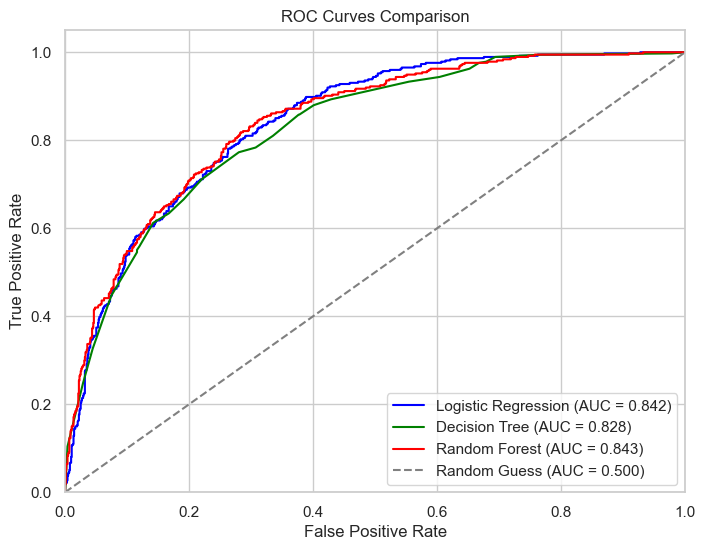

In [16]:
plt.figure(figsize=(8, 6))

# Plot ROC curve for each model
for results, color in zip([log_reg_results, dec_tree_results, rand_forest_results], ['blue', 'green', 'red']):
    fpr, tpr, _ = roc_curve(y_test, results['probs'])
    plt.plot(fpr, tpr, color=color, label=f"{results['Model']} (AUC = {results['ROC-AUC']:.3f})")

# Plot baseline
plt.plot([0, 1], [0, 1], color='grey', linestyle='--', label='Random Guess (AUC = 0.500)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend(loc='lower right')
plt.show()


## 8. Confusion Matrices

A confusion matrix summarizes the prediction results on a classification problem:
- **True Negatives (TN)**: Customers who stayed and were correctly predicted as staying.
- **False Positives (FP)**: Customers who stayed but were predicted as churned (Type I error).
- **False Negatives (FN)**: Customers who churned but were predicted as staying (Type II error).
- **True Positives (TP)**: Customers who churned and were correctly predicted as churned.

Let's visualize the confusion matrices using Seaborn heatmaps side-by-side.


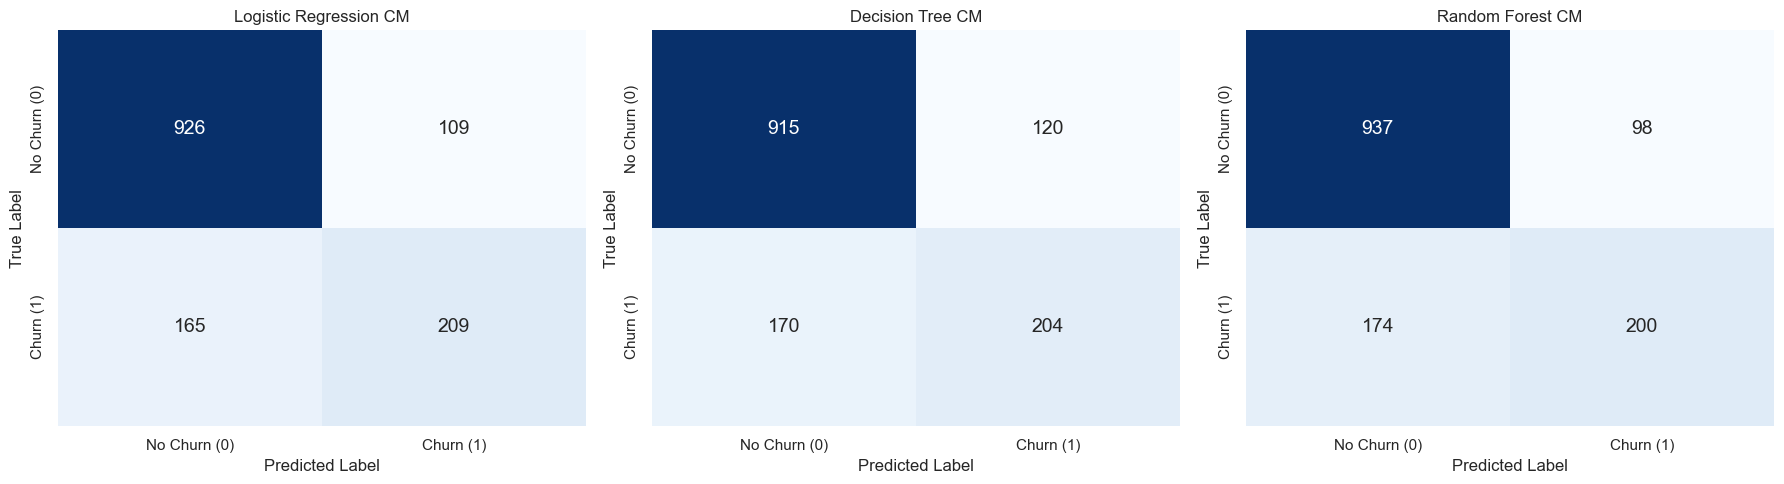

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
results_list = [log_reg_results, dec_tree_results, rand_forest_results]

for i, res in enumerate(results_list):
    cm = confusion_matrix(y_test, res['preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False,
                annot_kws={'size': 14})
    axes[i].set_title(f"{res['Model']} CM")
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')
    axes[i].set_xticklabels(['No Churn (0)', 'Churn (1)'])
    axes[i].set_yticklabels(['No Churn (0)', 'Churn (1)'])

plt.tight_layout()
plt.show()


## 9. Model Comparison & Feature Importance

Let's compare the metrics of our three models side-by-side in a table to determine which model performs best.


In [18]:
# Create comparison dataframe
comparison_data = []
for res in results_list:
    comparison_data.append({
        'Model': res['Model'],
        'Accuracy': res['Accuracy'],
        'Precision': res['Precision'],
        'Recall': res['Recall'],
        'F1-Score': res['F1-Score'],
        'ROC-AUC': res['ROC-AUC']
    })

df_comparison = pd.DataFrame(comparison_data).set_index('Model')
df_comparison


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.805536,0.657233,0.558824,0.604046,0.842068
Decision Tree,0.794180,0.629630,0.545455,0.584527,0.828358
Random Forest,0.806955,0.671141,0.534759,0.595238,0.842726


### 9.1 Feature Importance from Random Forest
Ensemble models like Random Forest allow us to extract feature importances, showing which variables had the most predictive power. This helps business stakeholders understand what is driving customer churn.


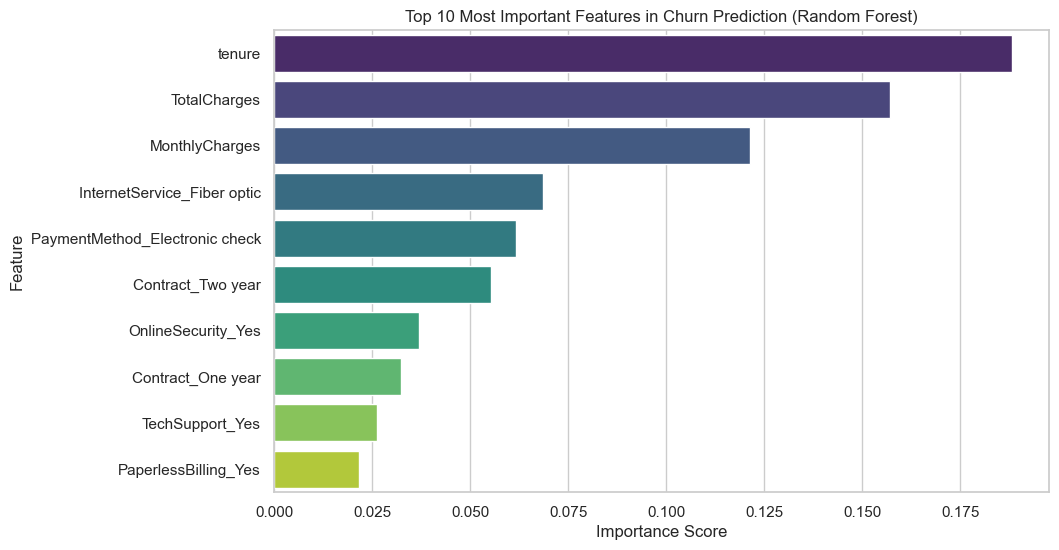

In [19]:
# Get feature importances from Random Forest
importances = rand_forest.feature_importances_
features = X.columns

# Create a DataFrame
df_importance = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot the top 10 features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=df_importance.head(10), palette='viridis')
plt.title('Top 10 Most Important Features in Churn Prediction (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()


## 10. Making Predictions on New Customer Samples

In a real-world production environment, once we have trained our final model, we want to use it to predict the churn risk of new customers. Let's create two new customer profiles and see how the model evaluates them:

- **Customer A (High Churn Risk profile)**: Month-to-month contract, low tenure (2 months), high monthly charges, electronic check payment, fiber optic internet, no tech support.
- **Customer B (Low Churn Risk profile)**: Two-year contract, high tenure (60 months), low monthly charges, credit card payment, DSL internet, has tech support.

We will write a prediction pipeline that takes raw customer dictionaries, structures them as a DataFrame, processes them using the same dummy columns, scales them, and outputs predictions.


In [20]:
# Define two new customer profiles (using raw categorical inputs as they would come from a database)
new_customers = [
    {
        'gender': 'Female',
        'SeniorCitizen': 1,
        'Partner': 'No',
        'Dependents': 'No',
        'tenure': 2,
        'PhoneService': 'Yes',
        'MultipleLines': 'No',
        'InternetService': 'Fiber optic',
        'OnlineSecurity': 'No',
        'OnlineBackup': 'No',
        'DeviceProtection': 'No',
        'TechSupport': 'No',
        'StreamingTV': 'No',
        'StreamingMovies': 'No',
        'Contract': 'Month-to-month',
        'PaperlessBilling': 'Yes',
        'PaymentMethod': 'Electronic check',
        'MonthlyCharges': 85.00,
        'TotalCharges': 170.00
    },
    {
        'gender': 'Male',
        'SeniorCitizen': 0,
        'Partner': 'Yes',
        'Dependents': 'Yes',
        'tenure': 60,
        'PhoneService': 'Yes',
        'MultipleLines': 'Yes',
        'InternetService': 'DSL',
        'OnlineSecurity': 'Yes',
        'OnlineBackup': 'Yes',
        'DeviceProtection': 'Yes',
        'TechSupport': 'Yes',
        'StreamingTV': 'Yes',
        'StreamingMovies': 'Yes',
        'Contract': 'Two year',
        'PaperlessBilling': 'No',
        'PaymentMethod': 'Credit card (automatic)',
        'MonthlyCharges': 65.00,
        'TotalCharges': 3900.00
    }
]

# 1. Convert to DataFrame
df_new = pd.DataFrame(new_customers)

# 2. Replicate One-Hot Encoding structure
# To do this correctly and robustly without data leakage, we align df_new's columns with X's columns
df_new_encoded = pd.get_dummies(df_new)
# Reindex the new dataframe with the training set columns, filling missing categories with 0
df_new_encoded = df_new_encoded.reindex(columns=X.columns, fill_value=0)

# 3. Scale numerical variables using the pre-fit scaler
df_new_scaled = df_new_encoded.copy()
df_new_scaled[num_cols_to_scale] = scaler.transform(df_new_encoded[num_cols_to_scale])

# 4. Generate predictions using our best model (Random Forest in terms of ROC-AUC)
rf_preds = rand_forest.predict(df_new_scaled)
rf_probs = rand_forest.predict_proba(df_new_scaled)[:, 1]

# 5. Display the results
for i, (pred, prob) in enumerate(zip(rf_preds, rf_probs)):
    customer_label = 'Customer A (High Risk)' if i == 0 else 'Customer B (Low Risk)'
    status = 'CHURN (1)' if pred == 1 else 'NO CHURN (0)'
    print(f'=== Prediction for {customer_label} ===')
    print(f'Predicted Status: {status}')
    print(f'Churn Probability: {prob:.2%}\n')


=== Prediction for Customer A (High Risk) ===
Predicted Status: CHURN (1)
Churn Probability: 71.86%

=== Prediction for Customer B (Low Risk) ===
Predicted Status: NO CHURN (0)
Churn Probability: 1.61%



## 11. Conclusion & Next Steps

Congratulations! You've built a complete end-to-end binary classification model for customer churn.

### Key Takeaways:
1. **Exploratory Data Analysis** allowed us to see that factors like *Month-to-month* contract structures and *Fiber optic* services are linked to higher churn rates.
2. **Data Preprocessing** (handling missing values, encoding categoricals, and feature scaling) is a required step before running machine learning algorithms.
3. **Multiple Models** were trained and evaluated. Although Logistic Regression is simpler, models like **Random Forest** often perform better on classification tasks due to their ability to capture non-linear relationships.
4. **Precision and Recall** are critical when classes are imbalanced or when business costs of errors differ. For instance, sending a retention offer to a customer who wasn't going to churn (False Positive) is cheaper than letting an actual churning customer leave (False Negative), making **Recall** a highly important metric here.

### Ideas for Further Exploration:
- **Hyperparameter Tuning**: Use `GridSearchCV` or `RandomizedSearchCV` to fine-tune the parameters of the Random Forest model (e.g., `n_estimators`, `max_depth`, `min_samples_split`).
- **Handle Class Imbalance**: Use techniques like SMOTE (Synthetic Minority Over-sampling Technique) or set the `class_weight='balanced'` parameter in classifiers.
- **Try Other Models**: Train advanced ensemble techniques like XGBoost, LightGBM, or Support Vector Machines (SVM).
